# Stochastic Volatility Inspired (SVI)
## Portion by: Aurora Hiveley

Stochastic Volatility Inspired (SVI) is a stochastic volatility model widely used to calibrate the implied volatility smile. A stochastic volatility model treats the variance of a stochastic process as a quantity which also varies randomly over time, in contrast to Black-Scholes's (inaccurate) assumption of constant volatility. SVI was originally created by Merrill Lynch in 1999 using the principles of the Heston model, and it now has many extensions including SSVI and SVI-JW. Researchers continue to refine SVI to better protect against arbitrage while maintaining the flexibility of the model. Due to its popularity at real-world options desks, this model will act as the "baseline" for our project when comparing the performance of other models.

## Set-Up
In this section, we import packages that have been used throughout the Erdos Institute's Quantitative Finance Boot Camp, and we import our pre-processed data before constructing a holdout data frame.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import yfinance as yf


from scipy.stats import normaltest
from statsmodels.stats.diagnostic import acorr_ljungbox

from scipy.interpolate import interp1d
from scipy.differentiate import derivative

sns.set_style('darkgrid')

We import the processed data, which spans the entirety of 2023 for 6 S&P funds: AAPL, NVDA, QQQ, SLV, SPX, and TSLA. See the README and/or the executive summary for more information about the data being used. The pipeline used to clean and process our data is also available in the repository, but note that the data being imported here has already been processed.

In [2]:
from google.colab import files
df = files.upload()

Saving surface_all.parquet to surface_all (2).parquet


In [3]:
df = pd.read_parquet("surface_all.parquet")

We will use only 80% of the data points in the data set on a given day to train the SVI model and construct a parametrization. Then, the model will be analyzed by checking its accuracy against the missing 20% of the data points. We will use the following to separate our data frame into two pieces: the holdout frame, and the remaining data points.

In [4]:
## written by Yvonne Ng for the purposes of this project, also linked in the github repo and used verbatim for each model

def make_holdout(frame, frac, min_vis, seed):
  rng = np.random.default_rng(seed)
  hold = pd.Series(False, index=frame.index)
  for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
    n = len(sl)
    n_hold = min(int(round(frac * n)), max(0, n - min_vis))
    if n_hold > 0:
      hold.loc[rng.choice(sl.index.values, size=n_hold, replace=False)] = True
  return hold

In [5]:
## craft the holdout dataset
# tickers: 'AAPL', 'NVDA', 'QQQ', 'SLV', 'SPX', 'TSLA'
# we will use SPX specifically for the sake of uniformity with other models, but this approach can be used for any ticker in the data set

TICKER = "SPX"

df = df[df["ticker"] == TICKER].copy().reset_index(drop=True)
# print(f"{TICKER}: {len(df)} quotes over {df['quote_date'].nunique()} days")

HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED = 0.20, 6, 0

df["is_holdout"] = make_holdout(df, HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED)

lvl = (df[~df["is_holdout"]].groupby(["ticker", "quote_date"])["iv"].median().rename("day_level").reset_index())
df = df.merge(lvl, on=["ticker", "quote_date"], how="left")
df["day_level"] = df["day_level"].fillna(df["iv"].median())

n_vis, n_hold = (~df["is_holdout"]).sum(), df["is_holdout"].sum()

df_train = df[df['is_holdout'] == False]
df_test = df[df['is_holdout'] == True]

## Stochastic Volatility Inspired

The SVI model uses the log-moneyness, which in turn is a function of strike price $K$ and forward $F$ where $F = S e^{rt}$. There are multiple parametrizations of SVI, but the most commonly used for its versatility is the raw parametrization:  
$$w(k) = a + b \left( \rho(k-m) + \sqrt{(k-m)^2 + \sigma^2} \right)$$

Here, the input $k$ is the log-moneyness $k = \log(K/F)$, and the parameters $a$, $b$, $\rho$, $m$, and $\sigma$ all vary the shape of the implied volatility smile as follows. Note that $\sigma$ is **not** volatility or variance, but a separate parameter (in spite of its similar name.) The output $w$ is the total variance, which is equivalent to $w = \sigma^2 \tau$ for an expiration time of $\tau$.

* $a$: Vertical translation of the curve
* $b$: Tightness of the curve, or the angle between put and call wings
* $\rho$: Counterclockwise rotation of the smile
* $m$: Horizontal translation of the curve
* $\sigma$: At-the-money curvature

To calibrate our parameters to a given data set, we will perform a least squares fit using the initial parameter guess:

- $a = 0.5*\min\{$ Total Variance$\}$
- $b = 0.1$
- $\rho = -0.5$
- $m = 0.1$
- $\sigma = 0.1$

The least squares fit is a function built in to the `optimize` package of the `scipy` library. Note that we minimize the least squares error for the implied variance, not the market price. Then we must compute the implied variance $w$ of the market data to use for our calibration. In this sense, we will calibrate or fit only a slice of the data taken with $\tau$. The entire implied volatility surface is obtained by stitching together each slice for a given $\tau$.


In [6]:
## implement and fit SVI
# the user will interface primarily with SVI_model. note that SVI_raw and parametrize_SVI are intermediary helpers

from scipy.optimize import least_squares
np.random.seed(0)

def SVI_slice(frame, tau, form ='iv'):
  '''
  SVI Slice for Dataframe with Expiration Time

  Inputs:
  frame: pd.DataFrame
  tau: expiration time used to slice data set
  form: str either 'iv' or 'var' for desired form of output. default is 'iv'
    var = implied variance sigma^2*T, the direct output of the raw SVI parametrization
    iv = implied volatility, computed from the implied variance and time to expiry tau
    eq = list of parameters [a,b,rho,m,sigma] used for parametrization

  Returns:
  Vector of values output by parametrized SVI using the input log moneyness column from data frame
  '''
  fr = frame[frame['tau']==tau]   # sliced data frame

  x = frame['log_moneyness']
  ivs = frame['iv']
  y = ivs**2*tau # define market total variance (w) to use for fit
  min_total_var = min(frame['total_var'])

  # compute parameters for SVI based on refined data
  c = parametrize_SVI(x,y,min_total_var)

  if form == 'var':
      result = SVI_raw(x,c[0],c[1],c[2],c[3],c[4])

  elif form == 'iv':
      result = SVI_w_to_IV(x,tau,c[0],c[1],c[2],c[3],c[4])

  elif form == 'eq':
      result = c

  else:
      result = []

  return result



def parametrize_SVI(x,y,min_total_var):
  '''
  Fit Parametrization of SVI
  Calculates the optimized parametrization of raw SVI by minimizing least squares

  Inputs:
  x: log moneyness
  y: implied variance
  min_total_var: minimum total variance over all data points (used for initial guess)

  Returns:
  Vector of fit parameters [a,b,rho,m,sigma] for raw SVI
  '''

  def residuals(c, x, y):
      # Return residual = fit - observed
      return (SVI_raw(x,c[0],c[1],c[2],c[3],c[4]) - y)

  # initial parameter guess
  c0 = np.array([0.5*min_total_var, 0.1, -0.5, 0.1, 0.1])

  # Compute solution providing initial guess c0, x input, and y input
  sol = least_squares(residuals, c0, args=(x,y))
  return(sol.x)



def SVI_raw(lm,a,b,rho,m,sigma):
    '''
    Raw SVI Model
    Inputs:
    x: log moneyness

    a: vertical translation
    b: tightness, or angle between put and call wings
    rho: counterclockwise rotation of the smile
    m: horizontal translation
    sigma: at-the-money curvature (NOTE: NOT VOLATILITY! DIFFERENT SIGMA)

    Returns:
    SVI predicted implied variance w = sigma^2*tau (where sigma is the volatility)
    '''

    return a + b*(rho*(lm-m) + np.sqrt((lm-m)**2 + sigma**2))



def SVI_w_to_IV(lm,tau,a,b,rho,m,sigma):
  '''
  Implied Volatility Computed by SVI

  Inputs:
  lm = log-moneyness
  tau = expiration time
  a,b,rho,m,sigma = parameters for raw SVI obtained from parametrize_SVI

  Returns:
  IVs computed from SVI with parameters a,b,r,ho,m,sigma
  '''
  w = SVI_raw(lm,a,b,rho,m,sigma)
  return np.sqrt(np.maximum(w/tau,0))  # if w/T = sigma^2 not positive, then return 0

With these functions, we will create one large data frame with the attributes from the original data set which will be the most useful for our analysis (e.g. strike, time to expiration, log-moneyness, etc.) and add new attributes for the predicted IV and implied variance using SVI. Note that we compile this overall data frame by considering each tau and producing a SVI slice for each individual value.

In [93]:
def SVI_surface(frame):
  '''
  SVI IV surface

  Input:
  frame = pd.DataFrame with columns log_moneyness, iv, tau

  Output:

  '''
  surface = pd.DataFrame()

  taus = frame['tau']
  unique_taus = sorted(taus.unique())

  for tau in unique_taus:
    frame1 = frame[frame['tau']== tau]

    slice_ivs = SVI_slice(frame1,tau,'iv')
    slice_vars = SVI_slice(frame1,tau,'var')

    dfmini = pd.concat([
        frame1['log_moneyness'],
        frame1['underlying_last'],
        frame1['mid'],
        frame1['strike'],
        frame1['tau'],
        frame1['total_var'],
        frame1['type'],
        frame1['is_holdout'],
        frame1['iv'].rename('market_iv'),
        (tau*frame1['iv']**2).rename('market_var'),
        slice_ivs.rename('svi_iv'),
        slice_vars.rename('svi_vars') ], axis = 1 )

    surface = pd.concat([surface, dfmini])

  return surface.sort_index()

To unify our findings across all models presented in this project, we will use two specific dates for the majority of our analysis: 12-29-2023 and 03-10-2023. Note that 12/29 represents the end of the year (and of our data set, chronologically) and 3/10 represents the date of the Silicon Valley Bank collapse.

In [94]:
qd = '2023-12-29'
df1 = df_train[df_train['quote_date']==qd]

taus = sorted(df1['tau'].unique())
print(f'There are {len(taus)} unique taus/SVI slices for {qd}')



qd = '2023-03-10'
df2 = df_train[df_train['quote_date']==qd]

taus = sorted(df2['tau'].unique())
print(f'There are {len(taus)} unique taus/SVI slices for {qd}')

There are 42 unique taus/SVI slices for 2023-12-29
There are 38 unique taus/SVI slices for 2023-03-10


In [95]:
# this cell takes ~ 2 minutes to run in google colabs, so please be patient

surf_dec29 = SVI_surface(df1)

surf_mar10 = SVI_surface(df2)

One last thing: we may also want to compare the spot price against the price predicted by SVI. In other words, we can use the calculated IV from SVI to reverse-engineer a spot price using Black-Scholes. So, we will add a column to each of our data frames with this predicted price, as well.

In [131]:
## copied from in-class code written during the Erdos QF boot camp
def bs_call(S0,K,sigma,t,r):
  '''
  Black-Scholes Call Price
  Inputs:
  S0: spot price
  K: strike price
  sigma: volatility
  t: time to expiration
  r: risk-free interest rate

  Returns:
  Black-Scholes Price of European Call Option
  '''

  d1 = (np.log(S0/K) + r+0.5*sigma**2*t)/(sigma*np.sqrt(t))
  d2 = d1 - sigma*np.sqrt(t)

  return S0*norm.cdf(d1) - np.exp(-r*t)*K*norm.cdf(d2)

def bs_put(S0,K,sigma,t,r):
    '''
    Black-Scholes Put Price
    Inputs:
    S0: spot price
    K: strike price
    sigma: volatility
    t: time to expiration
    r: risk-free interest rate

    Returns:
    Black-Scholes Price of European Put Option

    '''

    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))

    d2 = d1 - sigma*np.sqrt(t)

    return -S0*norm.cdf(-d1) + np.exp(-r*t)*K*norm.cdf(-d2)


## the price of call options using a volatility equal to the IV computed by SVI
def SVI_predicted_prices(frame):
  '''
  Predicted price using IV from SVI

  Input:
  frame: data frame with columns ['underlying_last'], ['strike'], ['tau'], and ['svi_iv']

  Output:
  vector containing prices obtained by plugging SVI's resulting IV into Black-Scholes
  '''
  # partition into calls and puts
  put_frame = frame[frame['type']=='put']
  call_frame = frame[frame['type']=='call']

  p_spots = put_frame['underlying_last']
  p_strikes = put_frame['strike']
  p_taus = put_frame['tau']
  p_sigmas = put_frame['svi_iv']

  c_spots = call_frame['underlying_last']
  c_strikes = call_frame['strike']
  c_taus = call_frame['tau']
  c_sigmas = call_frame['svi_iv']

  r = 0.04

  p_prices = bs_put(p_spots,p_strikes,p_sigmas,p_taus,r)
  c_prices = bs_call(c_spots,c_strikes,c_sigmas,c_taus,r)

  # stitch back together, sorted by index
  return(pd.concat([p_prices,c_prices]).sort_index())

In [132]:
surf_dec29 = pd.concat([surf_dec29,SVI_predicted_prices(surf_dec29).rename('SVI_price')], axis = 1)

surf_mar10 = pd.concat([surf_mar10,SVI_predicted_prices(surf_mar10).rename('SVI_price')], axis = 1)


## Implied Volatility Smiles

Here, we construct several implied volatility curves against a scatterplot of the datapoints used. This gives us a visual representations of our fit for a variety of parameters. First, we provide scatterplots comparing our model's computed IV to the IVs in the data set for randomly selected days. Since we used least squares with the IV to fit our model, this plot mostly serves as a "sanity check" to confirm that our model does what we expect it to. Next, we plot the maturity against the market's IV and the model's predicted IV and observe the general fitness.

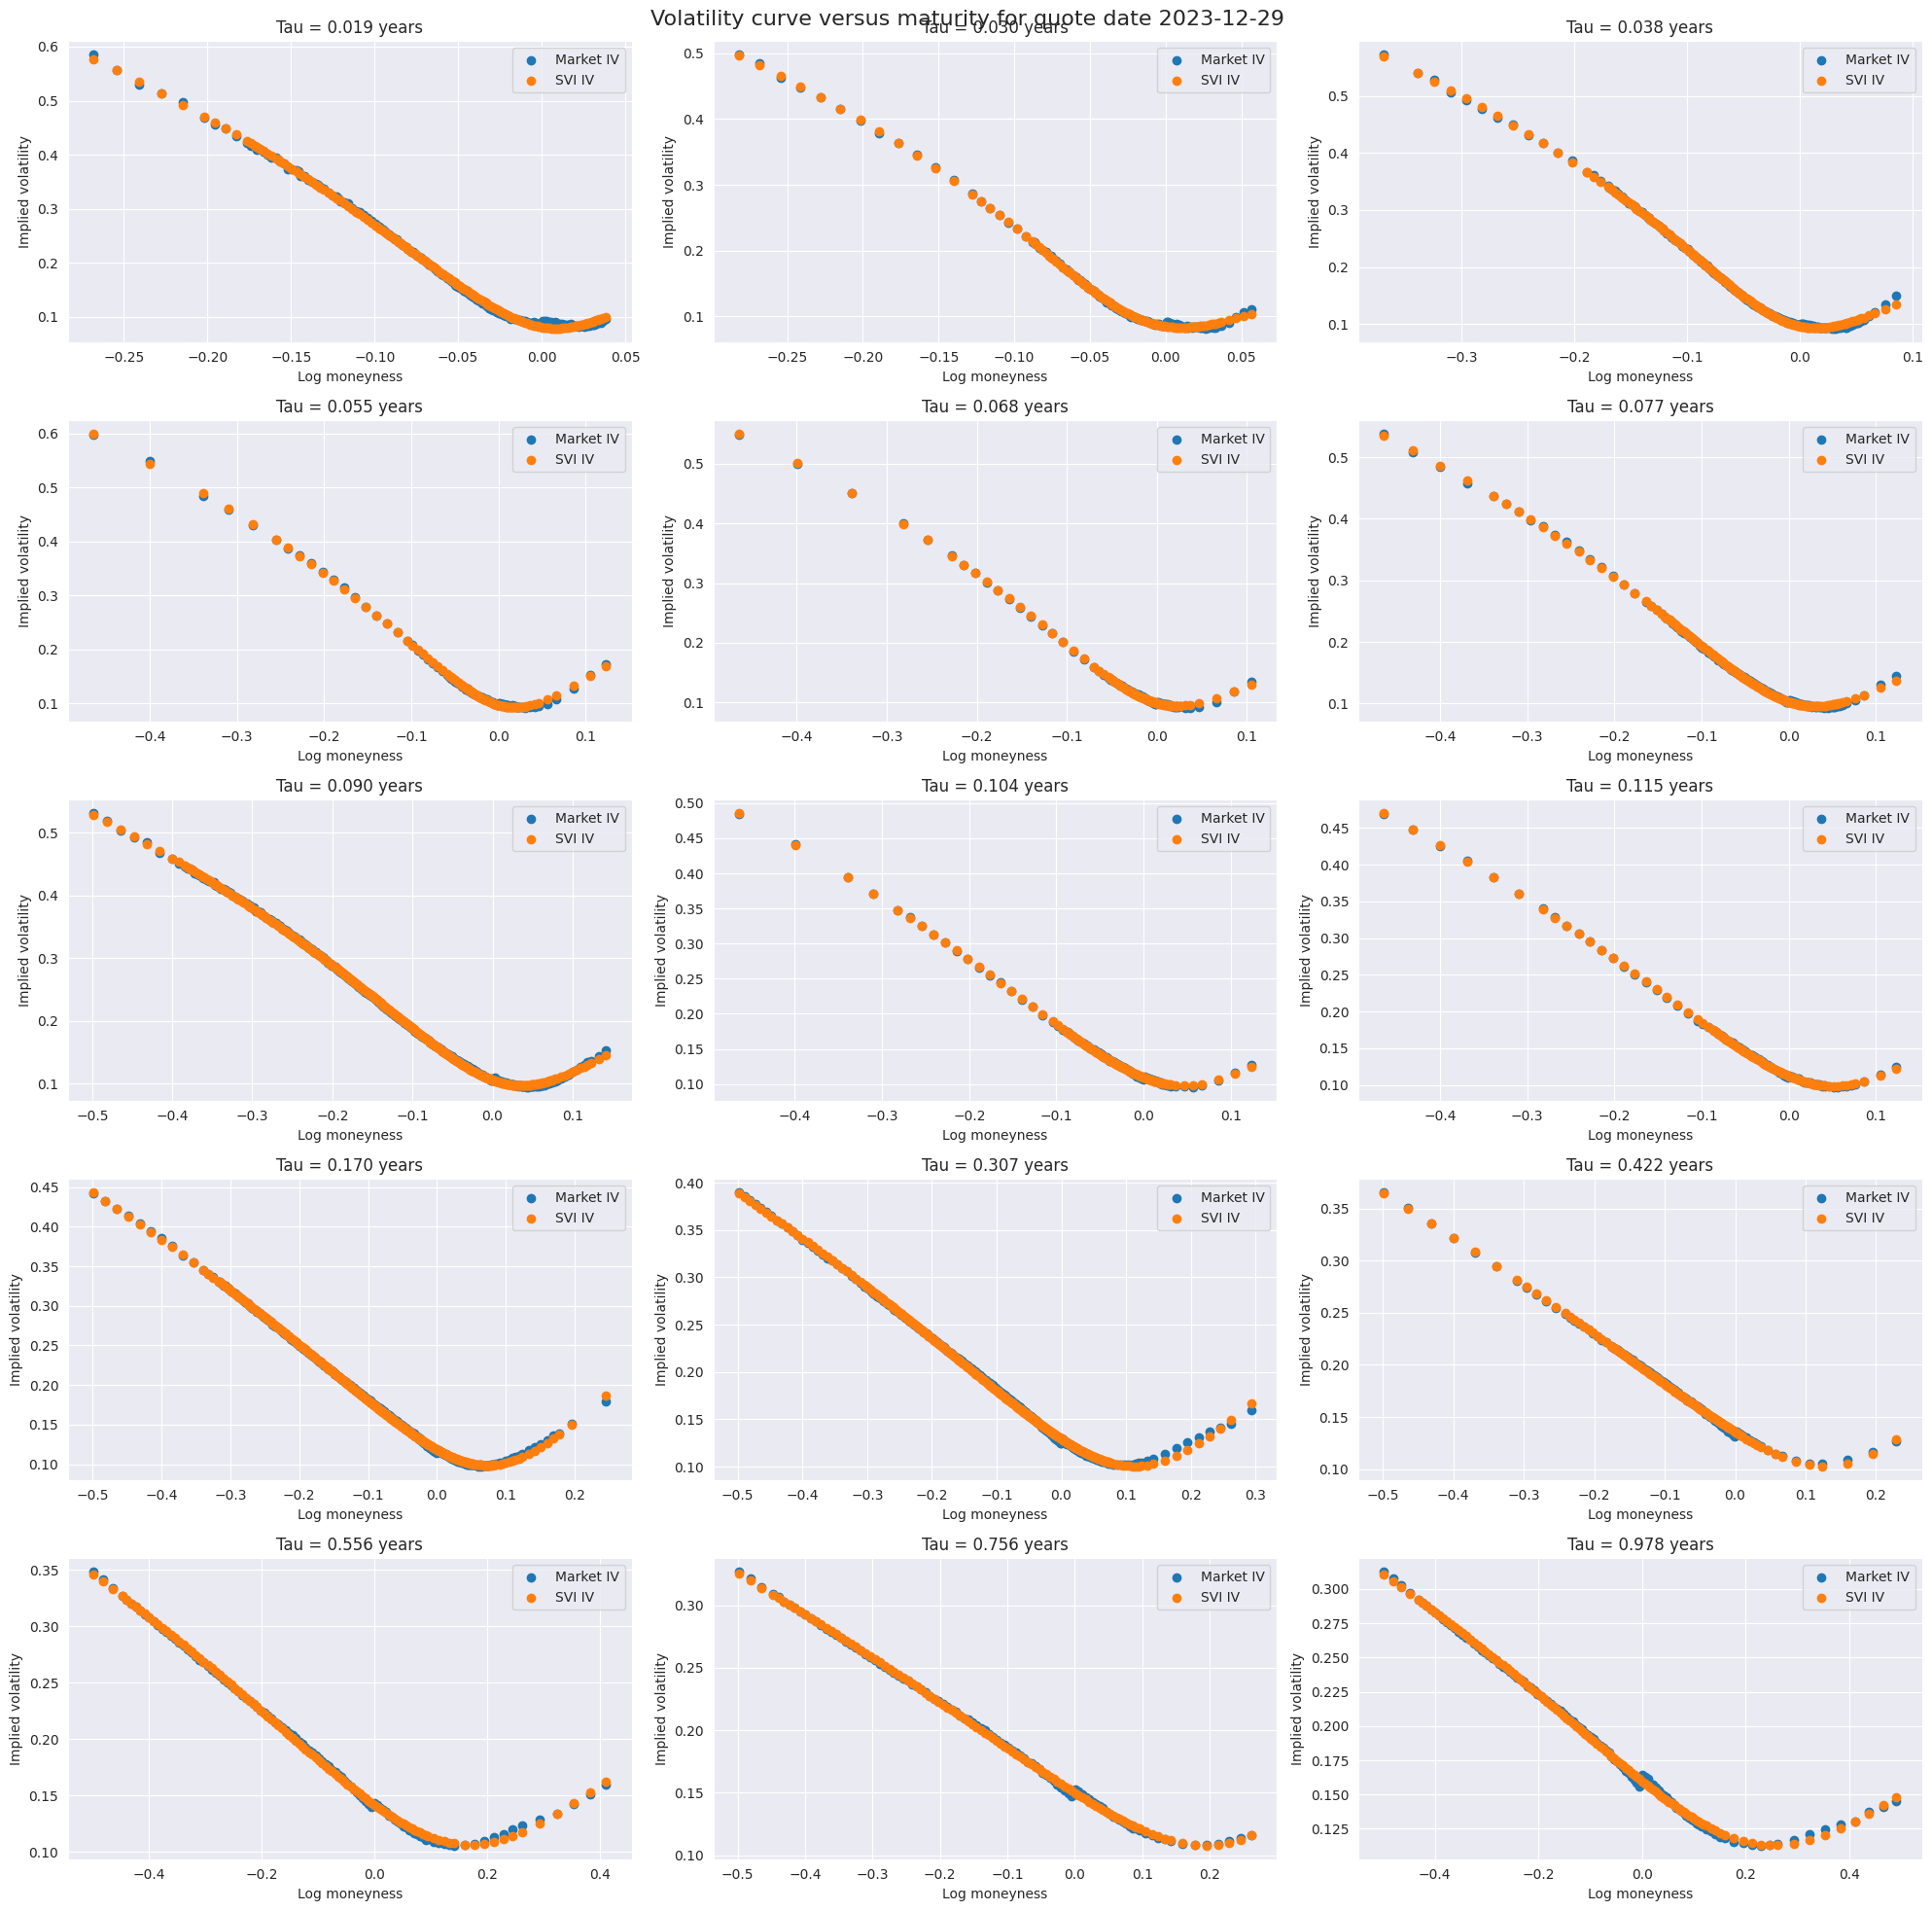

In [133]:
## plot IV smile slices for several maturities, tau
qd = '2023-12-29'
df1 = df[df['quote_date']==qd]

taus = np.sort(df1["tau"].round(3).unique())
n_plots = 15   # how many plots to build
used_taus = taus[np.linspace(0, len(taus)-1, n_plots).astype(int)]   # choose 12 evenly spaced taus, rounding to an integer, if needed

fig, axes = plt.subplots(5,3, figsize=(20, 20))
fig.suptitle(f"Volatility curve versus maturity for quote date {qd}", fontsize=16)
axes = np.array(axes).reshape(-1)

for ax, tau in zip(axes, used_taus):
    df2 = df1[df1["tau"].round(3) == tau]

    x = df2['log_moneyness']
    x1,y1 = zip(*sorted(zip(x, df2["iv"])))
    x2,y2 = zip(*sorted(zip(x, SVI_slice(df2,tau,'iv'))))

    ax.scatter(x1, y1, label="Market IV")
    ax.scatter(x2, y2, label="SVI IV")
    ax.set_title(f"Tau = {tau:.3f} years")
    ax.set_xlabel("Log moneyness")
    ax.set_ylabel("Implied volatility")
    ax.legend()

plt.tight_layout()
plt.show()

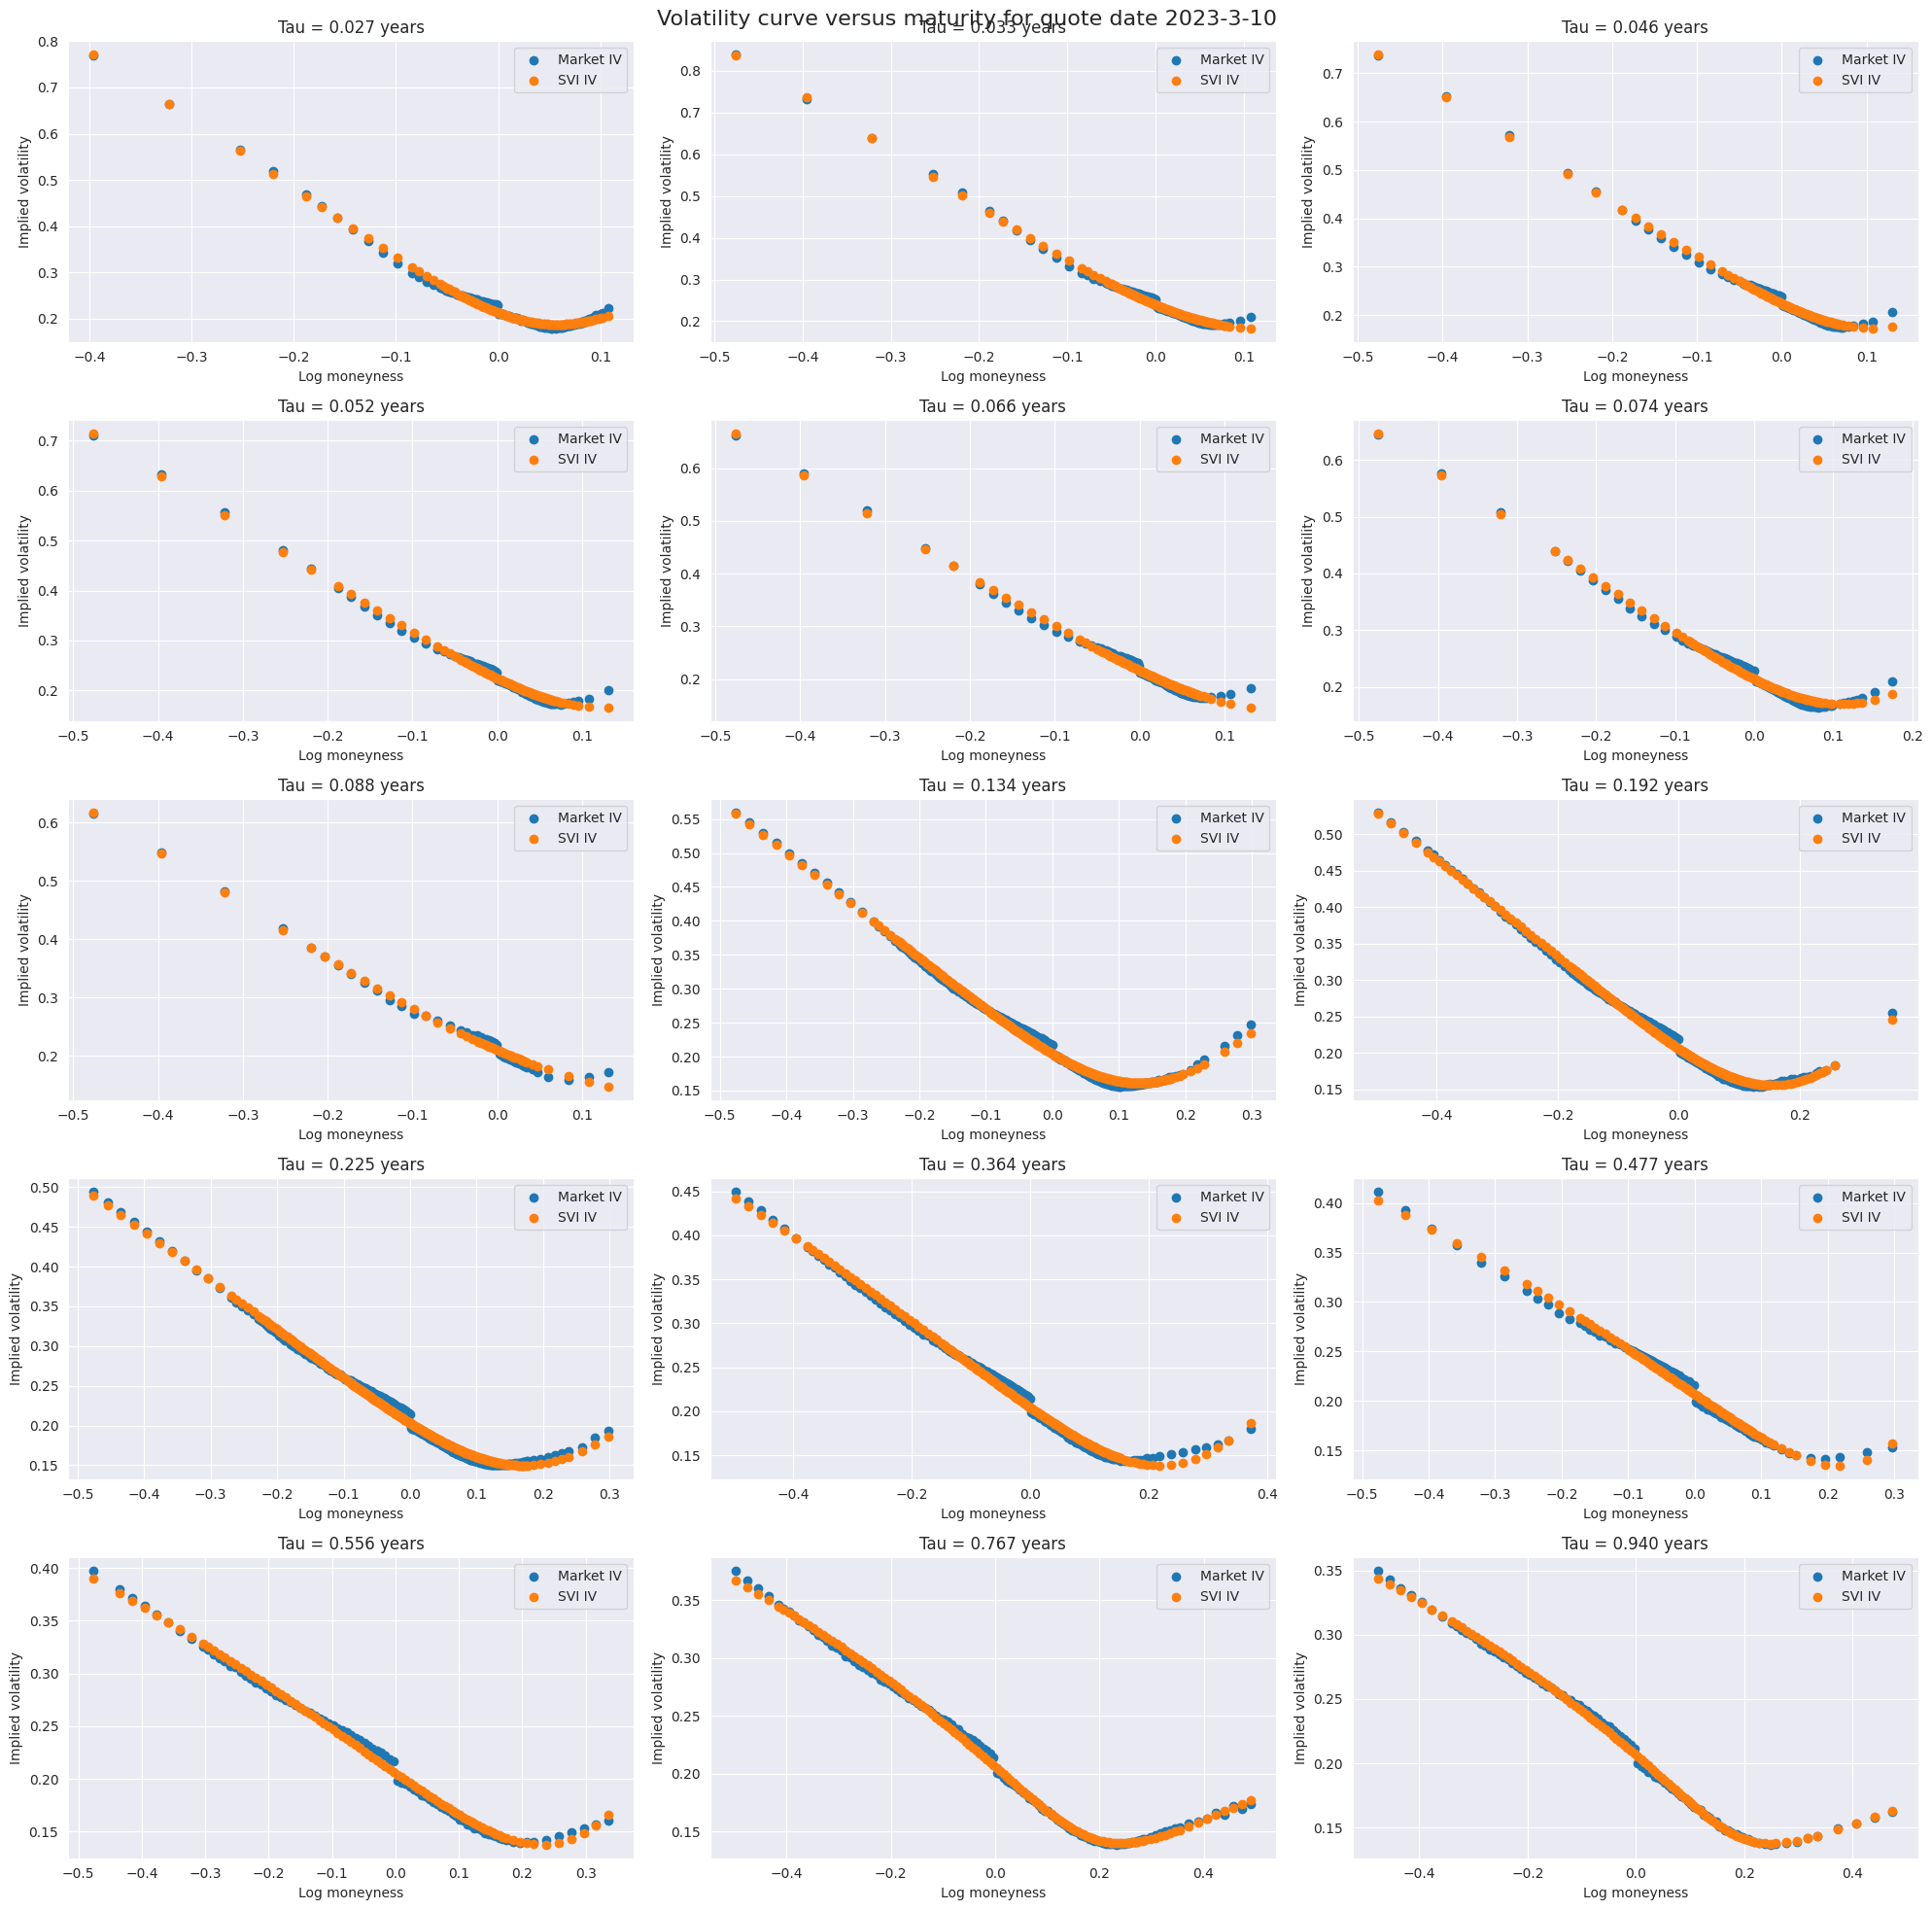

In [99]:
## plot IV smile slices for several maturities, tau
qd = '2023-3-10'
df1 = df[df['quote_date']==qd]

taus = np.sort(df1["tau"].round(3).unique())
n_plots = 15   # how many plots to build
used_taus = taus[np.linspace(0, len(taus)-1, n_plots).astype(int)]   # choose 15 evenly spaced taus, rounding to an integer, if needed

fig, axes = plt.subplots(5,3, figsize=(20, 20))
fig.suptitle(f"Volatility curve versus maturity for quote date {qd}", fontsize=16)
axes = np.array(axes).reshape(-1)

for ax, tau in zip(axes, used_taus):
    df2 = df1[df1["tau"].round(3) == tau]

    x = df2['log_moneyness']
    x1,y1 = zip(*sorted(zip(x, df2["iv"])))
    x2,y2 = zip(*sorted(zip(x, SVI_slice(df2,tau,'iv'))))

    ax.scatter(x1, y1, label="Market IV")
    ax.scatter(x2, y2, label="SVI IV")
    ax.set_title(f"Tau = {tau:.3f} years")
    ax.set_xlabel("Log moneyness")
    ax.set_ylabel("Implied volatility")
    ax.legend()

plt.tight_layout()
plt.show()

## Analysis: Holdout Data Error

To verify the accuracy of the model, we check the model's fit for the other 20% of the data points which were omitted from model training. This allows us to verify the model's stability.

In [100]:
# sanity check: are all of the expiration times in the holdout set also in the training set?
# meaning, can we match each holdout data point to some existing SVI curve/slice?

holdout_taus = sorted(df_test['tau'].round(3).unique())
train_taus = sorted(df_train['tau'].round(3).unique())

len(holdout_taus) == len(train_taus), holdout_taus == train_taus


(True, True)

In [134]:
def mean_squared_residuals(train_data, test_data):
  '''
  RMSE for Price and IV

  Inputs:
  train_data = pd.DataFrame representing data used to train the model
  test_data = pd.DataFrame representing holdout data ignored during model training

  Returns:
  RMSE for IV, RMSE for price
  '''

  holdout_taus = sorted(test_data['tau'].round(3).unique())

  price_residues = pd.Series([])
  iv_residues = pd.Series([])

  for tau in holdout_taus:
    holdout_at_tau = test_data[test_data['tau'].round(3) == tau]
    lm = holdout_at_tau['log_moneyness']

    ## what does SVI predict for price and iv?
    a,b,rho,m,sigma = SVI_slice(train_data, tau, form = 'eq')
    pred_ivs = SVI_w_to_IV(lm,tau,a,b,rho,m,sigma)

    frame_tau = pd.concat([holdout_at_tau, pred_ivs.rename('svi_iv')], axis =1)
    pred_prices = SVI_predicted_prices(frame_tau)

    if iv_residues.empty:
      iv_residues = pred_ivs - holdout_at_tau["iv"]
    if price_residues.empty:
      price_residues = pred_prices - holdout_at_tau["mid"]

    pd.concat( [iv_residues, pred_ivs - holdout_at_tau["iv"] ])
    pd.concat( [price_residues, pred_prices - holdout_at_tau["mid"] ])

  ## RMSE error for both
  iv_RMSE = np.sqrt( np.mean( iv_residues**2 ) )
  price_RMSE = np.sqrt( np.mean( price_residues**2 ) )

  # mean squares of residuals
  return iv_RMSE, price_RMSE

In [135]:
# compute RMSE for price and IV on both of our days of interest
qd = '2023-12-29'

train_data = df_train[df_train['quote_date']==qd]
test_data = df_test[df_test['quote_date']==qd]

rmse_dec29 = mean_squared_residuals(train_data, test_data)

print(f'The RMSE on {qd} for IVs is {rmse_dec29[0]}')
print(f'The RMSE on {qd} for prices is {rmse_dec29[1]}')


print('------------------------------------------------------------')

qd = '2023-03-10'

train_data = df_train[df_train['quote_date']==qd]
test_data = df_test[df_test['quote_date']==qd]

rmse_mar10 = mean_squared_residuals(train_data, test_data)

print(f'The RMSE on {qd} for IVs is {rmse_mar10[0]}')
print(f'The RMSE on {qd} for prices is {rmse_mar10[1]}')

The RMSE on 2023-12-29 for IVs is 0.057437783423657074
The RMSE on 2023-12-29 for prices is 26.537770712655455
------------------------------------------------------------
The RMSE on 2023-03-10 for IVs is 0.0419814461356529
The RMSE on 2023-03-10 for prices is 20.185133581063667


In [141]:
## how do these errors compare to the actual values?

print(f'Range of IVs for 2023-12-29:')
print(f'Min: {np.min(surf_dec29['market_iv'])}, Max: {np.max(surf_dec29['market_iv'])}, Average: {np.mean(surf_dec29['market_iv'])}')
print('------------------------------------')

print(f'Range of prices for 2023-12-29:')
print(f'Min: {np.min(surf_dec29['mid'])}, Max: {np.max(surf_dec29['mid'])}, Average: {np.mean(surf_dec29['mid'])}')
print('------------------------------------')

print(f'Range of SVI IVs for 2023-03-10:')
print(f'Min: {np.min(surf_mar10['market_iv'])}, Max: {np.max(surf_mar10['market_iv'])}, Average: {np.mean(surf_mar10['market_iv'])}')
print('------------------------------------')

print(f'Range of SVI prices for 2023-03-10:')
print(f'Min: {np.min(surf_mar10['mid'])}, Max: {np.max(surf_mar10['mid'])}, Average: {np.mean(surf_mar10['mid'])}')


print('-----------------------------------------------------')


avg_iv_dec29, avg_price_dec29 = np.mean(surf_dec29['market_iv']), np.mean(surf_dec29['mid'])
avg_iv_mar10, avg_price_mar10 = np.mean(surf_mar10['market_iv']), np.mean(surf_mar10['mid'])


print(f'RMSE on 2023-12-29 for IVs is {rmse_dec29[0]/np.mean(surf_dec29['market_iv'])*100}% of the mean market IV')
print(f'RMSE on 2023-12-29 for prices is {rmse_dec29[1]/np.mean(surf_dec29['mid'])*100}% of the mean market price')
print('-----------------------------------------------------')
print(f'RMSE on 2023-03-10 for IVs is {rmse_mar10[0]/np.mean(surf_mar10['market_iv'])*100}% of the mean market IV')
print(f'RMSE on 2023-03-10 for prices is {rmse_mar10[1]/np.mean(surf_mar10['mid'])*100}% of the mean market price')


Range of IVs for 2023-12-29:
Min: 0.07848, Max: 0.62873, Average: 0.18217748052441574
------------------------------------
Range of prices for 2023-12-29:
Min: 0.07500000000000001, Max: 386.65, Average: 28.22127588827665
------------------------------------
Range of SVI IVs for 2023-03-10:
Min: 0.13639, Max: 0.84574, Average: 0.2356250861287398
------------------------------------
Range of SVI prices for 2023-03-10:
Min: 0.07500000000000001, Max: 369.1, Average: 52.05300317316409
-----------------------------------------------------
RMSE on 2023-12-29 for IVs is 31.528476109295607% of the mean market IV
RMSE on 2023-12-29 for prices is 94.03462415276364% of the mean market price
-----------------------------------------------------
RMSE on 2023-03-10 for IVs is 17.81705285519355% of the mean market IV
RMSE on 2023-03-10 for prices is 38.778038442688946% of the mean market price


## Analysis: Static-Arbitrage Violations

SVI (and each other model employed in this project) is predicated on an assumption of no arbitrage. Then another test of the model's accuracy and efficacy is a measurement of arbitrage. We will count the number of violations to the "no arbitrage" rule used throughout this project by studying both calendar arbitrage and butterfly arbitrage. Note that SVI is notoriously difficult to engineer so that it protects against arbitrage. This is one major drawback of our "baseline" method which motivates the exploration of other models proposed in this project, in spite of SVI's ease of use.

In [103]:
def butterfly_viol_count(strikes,ivs,prices):
  '''
  Butterfly arbitrage violation counter

  Inputs:
  strikes: vector of strike prices
  ivs: vector of implied volatilities
  prices: vector of spot prices (usually 'mid' in data, or reverse engineered from SVI IV via Black-Scholes)

  Returns:
  array with information about butterfly arbitrage violations
  specifically, the trio of strike prices and corresponding IVs that are *not* convex
  '''
  if len(strikes) < 3:      # not enough data points to check
      return []

  # sort the points in order of strike
  x,y,z =  zip(*sorted(zip(strikes, prices,ivs)))
  violations = []

  # butterfly arbitrage violation if function not convex
  # i.e., for strikes K1 < K2 < K3 and corresponding IVs IV1, IV2, IV3
  # calculate the price P1, P2, P3 for each of these strikes and IVs using some method
  # check if Price( (K1 + K3)/2 ) <= 1/2(P1 + P3)
  # or P2 <= (1/2)(P1 + P3), so is 0.5*(P1 + P3) - P2 >= 0 ??
  for i in range(1, len(x) - 1):
      K1, K2, K3 = x[i-1], x[i], x[i+1]
      P1, P2, P3 = y[i-1], y[i], y[i+1]

      if (0.5*(P1+P3) - P2) < -1e-8:
        violations.append( {"strikes": (K1, K2, K3), "ivs": (z[i-1], z[i], z[i+1])})

  return violations


In [104]:
## butterfly arbitrage quantification for the market data and for svi on both days of interest
qd = '2023-03-10'
surf = surf_mar10

## market data
market_butterfly = butterfly_viol_count(surf['strike'], surf['market_iv'], surf['mid'])
print(f'Market data butterfly arbitrage violation counts on {qd}: {len(market_butterfly)}')

## svi
SVI_butterfly = butterfly_viol_count(surf['strike'], surf['svi_iv'], surf['SVI_price'] )
print(f'SVI model butterfly arbitrage violation counts on {qd}: {len(SVI_butterfly)}')


print('-----------------------------------------------')

qd = '2023-12-29'
surf = surf_dec29

## market data
market_butterfly = butterfly_viol_count(surf['strike'], surf['market_iv'], surf['mid'])
print(f'Market data butterfly arbitrage violation counts on {qd}: {len(market_butterfly)}')

## svi
SVI_butterfly = butterfly_viol_count(surf['strike'], surf['svi_iv'], surf['SVI_price'] )
print(f'SVI model butterfly arbitrage violation counts on {qd}: {len(SVI_butterfly)}')


Market data butterfly arbitrage violation counts on 2023-03-10: 1999
SVI model butterfly arbitrage violation counts on 2023-03-10: 1997
-----------------------------------------------
Market data butterfly arbitrage violation counts on 2023-12-29: 2068
SVI model butterfly arbitrage violation counts on 2023-12-29: 2196


In [105]:
def calendar_viol_count(strikes,taus,vars):
  '''
  Calender arbitrage violation counter

  Inputs:
  strikes: vector of strike prices
  taus: vector of times to expiration (tau)
  vars: vector of implied variances (w = sigma**2*T)

  Returns:
  array with information about calendar arbitrage violations
  specifically, the duo of strike prices and corresponding IVs that are *not* increasing with tau
  '''
  df = pd.concat([strikes.rename('strike'),taus.rename('tau'),vars.rename('var')], axis =1)

  if len(strikes) < 2:      # not enough data points to check
      return []

  unique_strikes = strikes.unique()

  # calendar arbitrage violation if, for a fixed strike K,
  # implied variance is not increasing with time to expiration (tau)

  for K in unique_strikes:
      dfK = df[df['strike']==K]

      # sort the points in order of tau
      taus_K,vars_K =  zip(*sorted(zip(dfK['tau'], dfK['var'])))
      violations = []

      for i in range(len(vars_K)-1):
        v1,v2 = vars_K[i], vars_K[i+1]

        if v2 - v1 < -1e-8:
          violations.append( {"taus": (taus_K[i], taus_K[i+1]), "ivs": (v1, v2)})

  return violations



In [106]:
## calendar arbitrage quantification for the market data and for svi on both days of interest
qd = '2023-03-10'
surf = surf_mar10

## market data
market_calendar = calendar_viol_count(surf['strike'], surf['tau'], surf['market_var'])
print(f'Market data calendar arbitrage violation counts on {qd}: {len(market_calendar)}')

## svi
SVI_calendar = calendar_viol_count(surf['strike'], surf['tau'], surf['svi_vars'] )
print(f'SVI model calendar arbitrage violation counts on {qd}: {len(SVI_calendar)}')


print('-----------------------------------------------')

qd = '2023-12-29'
surf = surf_dec29

## market data
market_calendar = calendar_viol_count(surf['strike'], surf['tau'], surf['market_var'])
print(f'Market data calendar arbitrage violation counts on {qd}: {len(market_calendar)}')

## svi
SVI_calendar = calendar_viol_count(surf['strike'], surf['tau'], surf['svi_vars'] )
print(f'SVI model calendar arbitrage violation counts on {qd}: {len(SVI_calendar)}')


Market data calendar arbitrage violation counts on 2023-03-10: 0
SVI model calendar arbitrage violation counts on 2023-03-10: 0
-----------------------------------------------
Market data calendar arbitrage violation counts on 2023-12-29: 0
SVI model calendar arbitrage violation counts on 2023-12-29: 0


## Summary of Results

SVI is generally favored at real-world options desks due to its ease of calibration and adaptability. The sample plots indicate that with a quick parametrization, the SVI model can easily capture the general shape of an implied volatility smile with accuracy. The RMSEs support the accuracy of the model, as the standard error for the IV is quite small for each of our chosen dates. While the RMSE is bigger for the prices predicted by SVI, we recall that RMSE is quite susceptible to outliers, so the larger range of the price data may contribute to our larger errors. However, SVI is notoriously bad at guarding against butterfly arbitrage, and we see this trend in our results as well. It is important to note that the number of butterfly violations for SVI is close to the number of butterfly violations seen in the original market data. So while the model does not improve upon arbitrage present in the market data, it also does not significantly worsen the market's trends.